# Chapitre 8 — Effet prix, effet revenu, effet substitution

## Question du chapitre

Quand le prix d'un bien change, comment décomposer exactement la variation de la quantité demandée entre effet substitution et effet revenu ?

## Idée à comprendre d'abord

Le chapitre 7 mesurait l'ampleur de la réaction de la demande avec l'élasticité. Ici, on change de question : on ne cherche plus seulement à savoir **de combien** la quantité varie, mais **pourquoi** elle varie.
Une variation de prix agit de deux façons en même temps :

1. elle modifie le **prix relatif** du bien ;
2. elle modifie le **pouvoir d'achat réel** du consommateur.

C'est pourquoi on décompose l'effet total en deux morceaux.

## 8.1. Décomposition de base

$$
\text{effet prix} = \text{effet substitution} + \text{effet revenu}
$$

## 8.2. Effet substitution

Quand $p_1$ augmente, le bien 1 devient relativement plus cher. Le consommateur tend donc à se reporter vers les autres biens.

Pour le bien dont le prix augmente, l'effet substitution est toujours orienté dans le sens d'une baisse de la demande.

## 8.3. Effet revenu

Une hausse du prix du bien 1 reduit le pouvoir d'achat reel du consommateur.
Pour isoler l'effet revenu, on oublie un instant que le bien 1 est devenu relativement plus cher et on regarde seulement l'effet de cet appauvrissement.
La question devient alors : parce qu'il est plus pauvre, le consommateur veut-il acheter plus ou moins du meme bien 1 ?
Si le bien 1 est normal, il en veut moins ; s'il est inferieur, il peut en vouloir plus parce qu'il renonce a des biens plus chers ; mais, en general, l'effet substitution domine quand meme, sauf dans le cas rare du bien de Giffen.
Exemple d'un bien de Giffen: un menage tres pauvre vit surtout de riz et achete parfois un peu de viande. Si le prix du riz augmente, il n'a presque plus les moyens d'acheter de viande ; pour simplement continuer a se nourrir, il reduit fortement la viande et achete finalement encore plus de riz, meme devenu plus cher.

## 8.4. Décomposition de Hicks

L'intention de Hicks est d'isoler un effet substitution aussi pur que possible.
Concretement, on part du panier optimal initial A, qui donne un certain niveau de satisfaction. Puis on imagine que le prix change, mais qu'on ajuste fictivement le revenu du consommateur juste assez pour qu'il puisse encore atteindre **la meme courbe d'indifference qu'au point A**.
Le "meme niveau d'utilite" designe donc simplement le niveau de satisfaction associe au choix initial, avant la variation de prix. On ne cherche pas a conserver le meme panier : on cherche a conserver la meme satisfaction, avec les nouveaux prix.
On peut alors dire : ce qui change d'abord vient du prix relatif seul ; ce qui reste vient de l'effet revenu.

## 8.5. Décomposition de Slutsky

L'intention de Slutsky est de separer les deux effets avec une regle plus concrete.
On change le prix relatif, mais on compense le revenu de sorte que **l'ancien panier reste achetable** aux nouveaux prix.
Les deux décompositions racontent donc la meme histoire, mais Hicks raisonne en niveau d'utilite, tandis que Slutsky raisonne en pouvoir d'achat de l'ancien panier.

## 8.6. Équation de Slutsky

Pour le bien $i$ et le prix du bien $j$ :

$$
\frac{\partial x_i}{\partial p_j} = \frac{\partial h_i}{\partial p_j} - x_j \frac{\partial x_i}{\partial R}
$$

- $x_i$ : demande marshallienne ;
- $h_i$ : demande compensée ;
- premier terme : effet substitution ;
- second terme : effet revenu.

Pour le prix propre, l'effet substitution compensé reste négatif :

$$
\frac{\partial h_i}{\partial p_i}<0
$$

## Erreur classique

Dire que l'effet substitution et l'effet revenu vont toujours dans le même sens. C'est vrai pour un bien normal, pas pour un bien inférieur.

---


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

FIG_DIR = Path("microeco_v5_figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.dpi": 160,
    "savefig.dpi": 200,
    "font.size": 11
})

def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", bbox_inches="tight")
    plt.savefig(FIG_DIR / f"{name}.svg", bbox_inches="tight")
    plt.show()


## Graphique — Décomposition de Hicks

**Ce qu'il faut voir.** Le passage de A à C est l'effet prix total. On le découpe en deux étapes : de A à B, l'**effet substitution** ; de B à C, l'**effet revenu**.

**Comment le lire vite.** Ici, la droite compensée de Hicks est choisie pour laisser au consommateur le **meme niveau d'utilite qu'en A**. Le point B reste donc sur la meme courbe d'indifference que A, mais avec la nouvelle pente de budget.

**Cas concret simple.** Si le prix du bien 1 augmente, le budget devient plus raide. Le consommateur passe d'abord de A vers B parce que le bien 1 est devenu relativement plus cher, puis de B vers C parce que son pouvoir d'achat reel baisse.

**Erreur à éviter.** Dans Hicks, B doit etre sur la meme courbe d'indifference que A. Si B est sur une autre courbe, on ne voit plus un effet substitution pur.


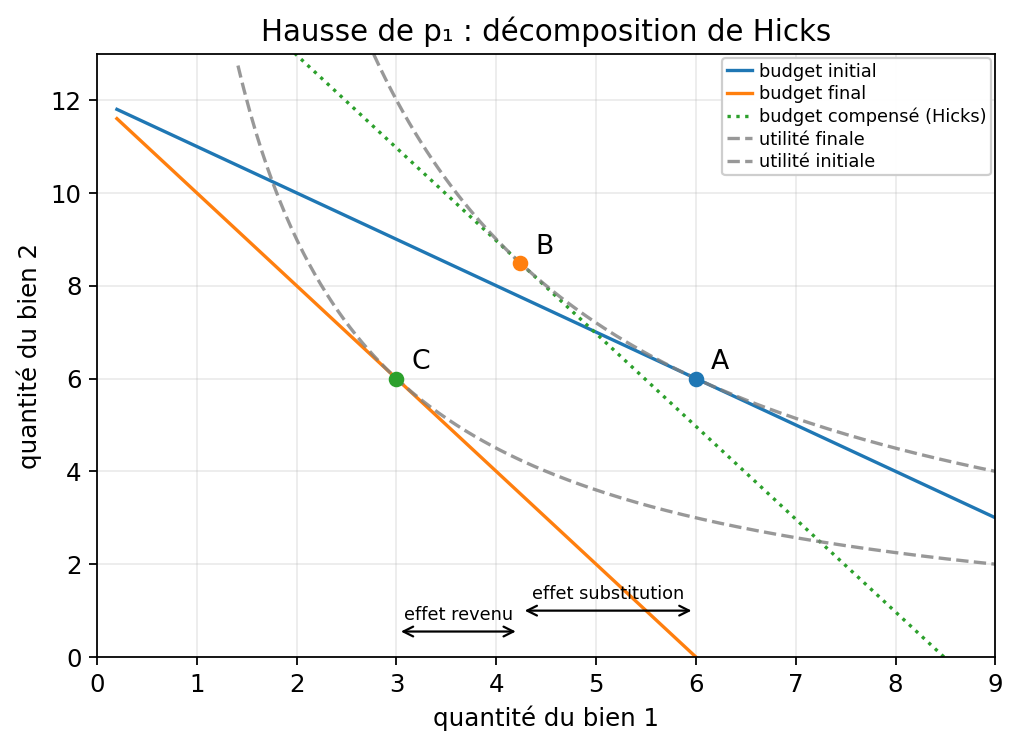

In [ ]:
# 3 Slutsky-Hicks decomposition
plt.figure(figsize=(6.5,4.8))
x=np.linspace(0.2,12,400)
# Hausse de p1 : budget initial y = 12 - x, budget final y = 12 - 2x.
# A = optimum initial, C = optimum final non compense, B = optimum compense (Hicks).
plt.plot(x,12-x,label='budget initial')
plt.plot(x,12-2*x,label='budget final')
plt.plot(x,16.97-2*x,linestyle=':',label='budget compensé (Hicks)')
for k, style, color, label in [(18,'--','tab:gray','utilité finale'), (36,'--','tab:gray','utilité initiale')]:
    y = k / x
    mask = (y >= 0) & (y <= 13)
    plt.plot(x[mask], y[mask], linestyle=style, color=color, alpha=.8, label=label)
pts={'A':(6,6),'B':(4.24,8.49),'C':(3,6)}
for k,(xx,yy) in pts.items():
    plt.scatter([xx],[yy],zorder=4); plt.text(xx+.15,yy+.2,k,fontsize=12)
plt.annotate('', xy=(4.24,1.0), xytext=(6.0,1.0), arrowprops=dict(arrowstyle='<->'))
plt.text(5.12, 1.16, 'effet substitution', ha='center', va='bottom', fontsize=8)
plt.annotate('', xy=(3.0,0.55), xytext=(4.24,0.55), arrowprops=dict(arrowstyle='<->'))
plt.text(3.62, 0.71, 'effet revenu', ha='center', va='bottom', fontsize=8)
plt.xlim(0,9); plt.ylim(0,13); plt.xlabel('quantité du bien 1'); plt.ylabel('quantité du bien 2')
plt.title('Hausse de p₁ : décomposition de Hicks')
plt.grid(True, alpha=.25); plt.legend(loc='upper right', fontsize=8, framealpha=.95, borderpad=.25, labelspacing=.25, handlelength=1.4, handletextpad=.4, borderaxespad=.25)
save_fig('03_decomposition_slutsky_hicks')


## Graphique — Décomposition de Slutsky

**Ce qu'il faut voir.** Le point final C est le meme que dans Hicks, mais le point intermediaire B n'est pas defini de la meme facon.

**Comment le lire vite.** Ici, la droite compensée de Slutsky est choisie pour que **l'ancien panier A reste juste achetable** apres la hausse de prix. Le point B se lit alors comme le nouvel optimum sur cette droite compensée.

**Cas concret simple.** Comme le consommateur peut encore acheter A aux nouveaux prix, la compensation est en general plus forte que chez Hicks. B se situe donc souvent sur une courbe d'indifference plus élevée que celle de A.

**Erreur à éviter.** Dans Slutsky, on ne cherche pas a garder la meme utilite qu'en A. On cherche seulement a garder le meme pouvoir d'achat du panier initial.


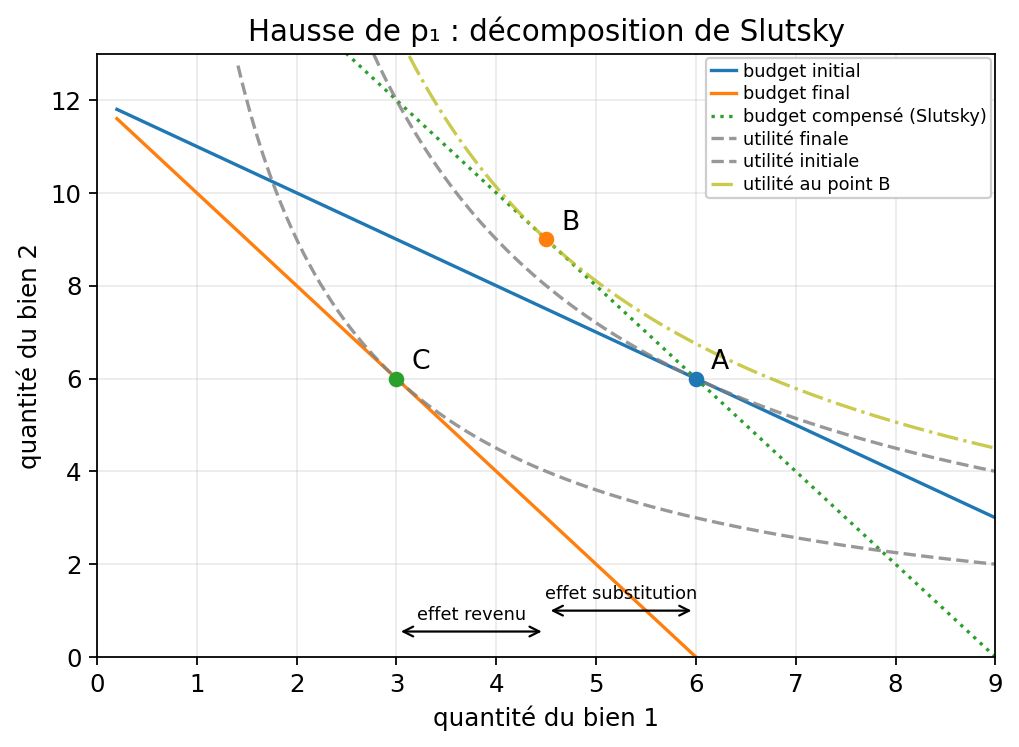

In [ ]:
# 3b Slutsky decomposition
plt.figure(figsize=(6.5,4.8))
x=np.linspace(0.2,12,400)
# Hausse de p1 : budget initial y = 12 - x, budget final y = 12 - 2x.
# A = optimum initial, C = optimum final non compense, B = optimum compense (Slutsky).
plt.plot(x,12-x,label='budget initial')
plt.plot(x,12-2*x,label='budget final')
plt.plot(x,18-2*x,linestyle=':',label='budget compensé (Slutsky)')
for k, style, color, label in [(18,'--','tab:gray','utilité finale'), (36,'--','tab:gray','utilité initiale'), (40.5,'-.','tab:olive','utilité au point B')] :
    y = k / x
    mask = (y >= 0) & (y <= 13)
    plt.plot(x[mask], y[mask], linestyle=style, color=color, alpha=.8, label=label)
pts={'A':(6,6),'B':(4.5,9),'C':(3,6)}
for k,(xx,yy) in pts.items():
    plt.scatter([xx],[yy],zorder=4); plt.text(xx+.15,yy+.2,k,fontsize=12)
plt.annotate('', xy=(4.5,1.0), xytext=(6.0,1.0), arrowprops=dict(arrowstyle='<->'))
plt.text(5.25, 1.16, 'effet substitution', ha='center', va='bottom', fontsize=8)
plt.annotate('', xy=(3.0,0.55), xytext=(4.5,0.55), arrowprops=dict(arrowstyle='<->'))
plt.text(3.75, 0.71, 'effet revenu', ha='center', va='bottom', fontsize=8)
plt.xlim(0,9); plt.ylim(0,13); plt.xlabel('quantité du bien 1'); plt.ylabel('quantité du bien 2')
plt.title('Hausse de p₁ : décomposition de Slutsky')
plt.grid(True, alpha=.25); plt.legend(loc='upper right', fontsize=8, framealpha=.95, borderpad=.25, labelspacing=.25, handlelength=1.4, handletextpad=.4, borderaxespad=.25)
save_fig('03b_decomposition_slutsky')
